<a href="https://colab.research.google.com/github/altaseb12/school/blob/master/pyhton_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [1]:
import sqlite3
import pandas as pd
from itertools import combinations

Create Database

In [2]:
# Create SQLite database

conn = sqlite3.connect('sales.db')

# Create cursor object
cursor = conn.cursor()

print("Database Connected Successfully")

Database Connected Successfully


Table

In [3]:
# Create Sales table

cursor.execute("""

CREATE TABLE Sales (

    Sale_ID INTEGER PRIMARY KEY,
    Product TEXT,
    Region TEXT,
    Year INTEGER,
    Sales_Amount REAL

)

""")

conn.commit()

print("Table Created Successfully")

Table Created Successfully


Insert Sample

In [4]:
# Insert sample records

sales_data = [

    (1, 'Laptop', 'Addis Ababa', 2024, 50000),
    (2, 'Laptop', 'Bahir Dar', 2024, 30000),
    (3, 'Phone', 'Addis Ababa', 2024, 20000),
    (4, 'Phone', 'Bahir Dar', 2024, 15000),
    (5, 'Laptop', 'Addis Ababa', 2025, 60000),
    (6, 'Phone', 'Addis Ababa', 2025, 25000),
    (7, 'Tablet', 'Adama', 2025, 18000),
    (8, 'Tablet', 'Bahir Dar', 2024, 22000)

]

cursor.executemany("""

INSERT INTO Sales
VALUES (?, ?, ?, ?, ?)

""", sales_data)

conn.commit()

print("Data Inserted Successfully")

Data Inserted Successfully


Display values

In [5]:
# Display Sales table

query = "SELECT * FROM Sales"

df = pd.read_sql_query(query, conn)

print(df)

   Sale_ID Product       Region  Year  Sales_Amount
0        1  Laptop  Addis Ababa  2024       50000.0
1        2  Laptop    Bahir Dar  2024       30000.0
2        3   Phone  Addis Ababa  2024       20000.0
3        4   Phone    Bahir Dar  2024       15000.0
4        5  Laptop  Addis Ababa  2025       60000.0
5        6   Phone  Addis Ababa  2025       25000.0
6        7  Tablet        Adama  2025       18000.0
7        8  Tablet    Bahir Dar  2024       22000.0


OLAP Query

In [6]:
# Total sales by product

query = """

SELECT
    Product,
    SUM(Sales_Amount) AS Total_Sales

FROM Sales

GROUP BY Product

"""

result = pd.read_sql_query(query, conn)

print(result)

  Product  Total_Sales
0  Laptop     140000.0
1   Phone      60000.0
2  Tablet      40000.0


Multi-Dimensional OLAP Query

In [7]:
# Sales by Product and Region

query = """

SELECT
    Product,
    Region,
    SUM(Sales_Amount) AS Total_Sales

FROM Sales

GROUP BY Product, Region

"""

result = pd.read_sql_query(query, conn)

print(result)

  Product       Region  Total_Sales
0  Laptop  Addis Ababa     110000.0
1  Laptop    Bahir Dar      30000.0
2   Phone  Addis Ababa      45000.0
3   Phone    Bahir Dar      15000.0
4  Tablet        Adama      18000.0
5  Tablet    Bahir Dar      22000.0


Load Data into Pandas

In [8]:
# Load full dataset

df = pd.read_sql_query("SELECT * FROM Sales", conn)

print(df)

   Sale_ID Product       Region  Year  Sales_Amount
0        1  Laptop  Addis Ababa  2024       50000.0
1        2  Laptop    Bahir Dar  2024       30000.0
2        3   Phone  Addis Ababa  2024       20000.0
3        4   Phone    Bahir Dar  2024       15000.0
4        5  Laptop  Addis Ababa  2025       60000.0
5        6   Phone  Addis Ababa  2025       25000.0
6        7  Tablet        Adama  2025       18000.0
7        8  Tablet    Bahir Dar  2024       22000.0


Construct OLAP Data Cube

In [9]:
# Define dimensions

dimensions = ['Product', 'Region', 'Year']

# Generate cube aggregations

for i in range(len(dimensions) + 1):

    for combo in combinations(dimensions, i):

        print("\n===================================")

        # Grand total
        if len(combo) == 0:

            print("GRAND TOTAL")

            total = df['Sales_Amount'].sum()

            print(total)

        else:

            print("Cube Dimension:", combo)

            cube = df.groupby(list(combo))['Sales_Amount'].sum().reset_index()

            print(cube)


GRAND TOTAL
240000.0

Cube Dimension: ('Product',)
  Product  Sales_Amount
0  Laptop      140000.0
1   Phone       60000.0
2  Tablet       40000.0

Cube Dimension: ('Region',)
        Region  Sales_Amount
0        Adama       18000.0
1  Addis Ababa      155000.0
2    Bahir Dar       67000.0

Cube Dimension: ('Year',)
   Year  Sales_Amount
0  2024      137000.0
1  2025      103000.0

Cube Dimension: ('Product', 'Region')
  Product       Region  Sales_Amount
0  Laptop  Addis Ababa      110000.0
1  Laptop    Bahir Dar       30000.0
2   Phone  Addis Ababa       45000.0
3   Phone    Bahir Dar       15000.0
4  Tablet        Adama       18000.0
5  Tablet    Bahir Dar       22000.0

Cube Dimension: ('Product', 'Year')
  Product  Year  Sales_Amount
0  Laptop  2024       80000.0
1  Laptop  2025       60000.0
2   Phone  2024       35000.0
3   Phone  2025       25000.0
4  Tablet  2024       22000.0
5  Tablet  2025       18000.0

Cube Dimension: ('Region', 'Year')
        Region  Year  Sales_Amoun

Roll-Up Example summarization

In [10]:
# Roll-Up Example

rollup = df.groupby(['Product'])['Sales_Amount'].sum().reset_index()

print("Roll-Up Result")

print(rollup)

Roll-Up Result
  Product  Sales_Amount
0  Laptop      140000.0
1   Phone       60000.0
2  Tablet       40000.0


Drill-Down Operation

In [11]:
# Drill-Down Example

drilldown = df.groupby(
    ['Product', 'Region', 'Year']
)['Sales_Amount'].sum().reset_index()

print("Drill-Down Result")

print(drilldown)

Drill-Down Result
  Product       Region  Year  Sales_Amount
0  Laptop  Addis Ababa  2024       50000.0
1  Laptop  Addis Ababa  2025       60000.0
2  Laptop    Bahir Dar  2024       30000.0
3   Phone  Addis Ababa  2024       20000.0
4   Phone  Addis Ababa  2025       25000.0
5   Phone    Bahir Dar  2024       15000.0
6  Tablet        Adama  2025       18000.0
7  Tablet    Bahir Dar  2024       22000.0


Slice Operation

In [12]:
# Slice Example

slice_data = df[df['Year'] == 2024]

print(slice_data)

   Sale_ID Product       Region  Year  Sales_Amount
0        1  Laptop  Addis Ababa  2024       50000.0
1        2  Laptop    Bahir Dar  2024       30000.0
2        3   Phone  Addis Ababa  2024       20000.0
3        4   Phone    Bahir Dar  2024       15000.0
7        8  Tablet    Bahir Dar  2024       22000.0


Dice Operation

In [13]:
# Dice Example

dice_data = df[
    (df['Product'] == 'Laptop') &
    (df['Region'] == 'Addis Ababa')
]

print(dice_data)

   Sale_ID Product       Region  Year  Sales_Amount
0        1  Laptop  Addis Ababa  2024       50000.0
4        5  Laptop  Addis Ababa  2025       60000.0


Visualize OLAP Result

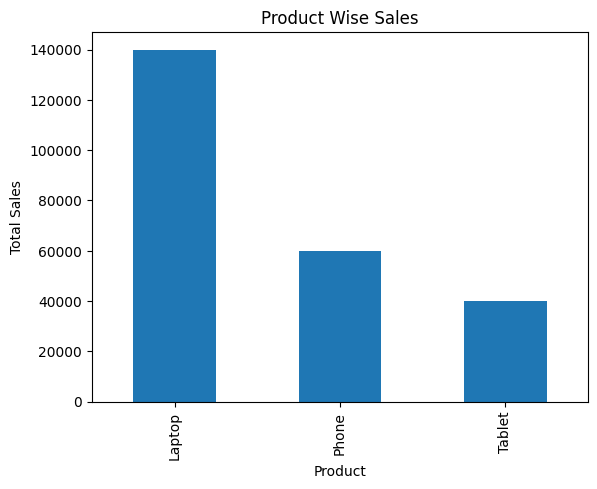

In [14]:
import matplotlib.pyplot as plt

# Product-wise sales

sales_chart = df.groupby('Product')['Sales_Amount'].sum()

sales_chart.plot(kind='bar')

plt.title("Product Wise Sales")

plt.xlabel("Product")

plt.ylabel("Total Sales")

plt.show()

Close database

In [15]:
conn.close()

print("Database Connection Closed")

Database Connection Closed
